# Example: Building a Maximum-Utility Portfolio Allocator

The L7b lecture computes a preference weight for each firm from the single index model (SIM) and the state of the market. Which firms do these weights put in the basket, how much of each do we buy, and how does a portfolio that re-solves this allocation through the year compare with portfolios we buy once and hold?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Compute the market inputs of the preference model:__ The preference model reads the market through a moving-average crossover signal and a smoothed recent growth rate of SPY. We'll compute both for every trading day of 2025 from prices available before each decision.
> * __Select the basket and split the budget:__ Each firm's preference weight combines its SIM intercept and beta with the two market inputs. We'll read the signs as the basket, split the budget with Cobb–Douglas utility, and compare the weights with the L7a minimum-variance and tangent portfolios.
> * __Run the allocator through a year of data:__ The course package has an engine that re-solves the allocation on a schedule and keeps the account self-financing. We'll run it daily and monthly through 2025, with one CES variant, and compare the wealth paths with buy-and-hold portfolios and SPY.

In this example, we use SIM parameters estimated from 2014 to 2024 data and SPY prices through the day before each decision. The allocator trades at the close on its rebalance days.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
We use daily prices of [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) firms and SPY, with 2014 to 2024 for training and 2025 for testing.

Let's load the training data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep the tickers with as many price records as `AAPL`, and store them in `dataset::Dict{String,DataFrame}`:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

We also load the SIM parameters saved by the L6b estimation example, using [the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/basic_usage/#FileIO-interface). For each firm, the archive holds $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and the residual variance $s^{2}_{g,\varepsilon,i}$. It also holds the market's training mean $g^{\prime}_{M}$ and variance $s^{2}_{g,M}$.

After checking the archive's variance convention, we store these in `sim_parameters::Dict{String,NamedTuple}`, `g_market_mean::Float64`, and `σ²_market::Float64`:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) ",
        "on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10]); ",
        "growth definition: $(archive["growth_definition"])")

    # checks -
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture

    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31; growth definition: g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted


### Constants
Finally, we set the time step, the initial wealth, the risk-free growth rate, the three moving-average windows, the share floor, the transaction cost rate, the rebalancing schedule, and the CES elasticity we test. The comments below give their meaning and units.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth W_P(0) (units: USD)
g_f = 0.041; # risk-free growth rate (units: 1/years), from a 4.16% one-year Treasury yield at the end of 2024
L_short = 21; # short exponential moving average window of the SPY price (trading days)
L_long = 63; # long exponential moving average window of the SPY price (trading days)
L_growth = 252; # window of the exponential moving average of the daily market growth rate (trading days): one trading year
n_min = 0.01; # share floor the allocator targets for every firm (units: shares); the engine sizes to the post-cost budget, so executed floors sit a hair below
c = 5e-4; # transaction cost rate (USD of cost per USD of gross notional traded): 5 basis points
schedule_days = 21; # monthly schedule: the engine re-solves the allocation every 21 trading days
η_CES = 0.5; # CES elasticity of substitution for the CES run (dimensionless): below one moves toward equal share counts, which puts more dollars in expensive firms

___

## Task 1: Compute the Market Inputs Through 2025
In this task, we choose our firms, pull their SIM parameters, and compute both market inputs for every trading day of 2025 from SPY prices through the previous day.

### Choose the firms
We start from the thirteen firms used in L6a and L7a, stored in `my_list_of_tickers::Array{String,1}`. If the L6b client interview files have been copied into this notebook's `data` folder, we use the list in `data/my-tickers.csv` instead:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L6a and L7a

# Use the client interview's list instead, if the interview has written one -
path_to_client_tickers = joinpath(_PATH_TO_DATA, "my-tickers.csv"); # copied from the L6b client interview
if (isfile(path_to_client_tickers))
    my_list_of_tickers = String.(CSV.read(path_to_client_tickers, DataFrame).ticker); # String.(...) converts CSV's compact strings
end
println("M = $(length(my_list_of_tickers)) firms: $(join(my_list_of_tickers, ", "))")

M = 30 firms: GOOG, DIS, NWS, HD, NKE, LOW, SYY, EL, ADM, BRK.B, V, L, SYK, A, MTD, AME, HON, ITW, APH, ACN, MSFT, ECL, PPG, AVY, PLD, BXP, ARE, AES, CNP, NRG


### Pull the SIM parameters
We pull the intercepts $\hat{\alpha}_{i}$ (inverse years) and the betas $\hat{\beta}_{i}$ of our firms. The preference model raises $\beta_{i}$ to a real power, so we check that every beta is positive.

We store them in `α̂::Array{Float64,1}` and `β̂::Array{Float64,1}`:

In [7]:
α̂, β̂ = let

    # SIM parameters for our firms -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)

    # checks -
    @assert all(β̂ .> 0) # the preference model raises β to a real power, so every β must be positive

    (α̂, β̂); # return
end;
println("β̂ ranges from $(round(minimum(β̂), digits=3)) to $(round(maximum(β̂), digits=3)); all positive")

β̂ ranges from 0.823 to 1.193; all positive


### Build the price matrix
The allocator trades at the close, so a market-on-close order fills at the closing price. We check that our firms and SPY share the same trading dates, then store the 2025 close prices in the matrix `S_2025::Array{Float64,2}` (rows are trading days, columns are firms in the order of `my_list_of_tickers`) and the SPY close prices in `spy_2025::Array{Float64,1}`:

In [8]:
S_2025, spy_2025 = let

    # close prices (USD/share) -
    S_2025 = hcat([dataset_2025[ticker][:, :close] for ticker ∈ my_list_of_tickers]...); # N × |𝒫|
    spy_2025 = dataset_2025["SPY"][:, :close];

    println("2025: $(size(S_2025, 1)) trading days, $(size(S_2025, 2)) firms; ",
        "first day $(Date(dataset_2025["AAPL"][1, :timestamp])), last day $(Date(dataset_2025["AAPL"][end, :timestamp]))")

    # checks: every series must have the same trading dates as AAPL -
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp # aligned training dates
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp # aligned 2025 dates
    end

    (S_2025, spy_2025); # return
end;

2025: 250 trading days, 30 firms; first day 2025-01-02, last day 2025-12-31


### Compute the market inputs
The preference model reads the market through two numbers on each decision day $t$: the market-state signal $\xi_{t}$ and the recent market growth rate $\tilde{g}_{M,t}$. As in the lecture, the signal is the scaled crossover of a short ($L_{\text{short}} = 21$ days) and a long ($L_{\text{long}} = 63$ days) exponential moving average (EMA) of the SPY close price:

$$
\xi_{t} = -G\left(\frac{\bar{S}^{\text{short}}_{t}}{\bar{S}^{\text{long}}_{t}} - 1\right)
$$

The short EMA follows the last few weeks and the long EMA the last quarter, so the ratio says where recent prices sit against the quarter's average:

* $\bar{S}^{\text{short}}_{t} > \bar{S}^{\text{long}}_{t}$: the ratio is above one, so $\xi_{t} < 0$ and the signal is __bullish__. Recent prices sit above the quarter's average: the market has been rising this quarter.
* $\bar{S}^{\text{short}}_{t} = \bar{S}^{\text{long}}_{t}$: $\xi_{t} = 0$ and the signal is __neutral__, so the preference weights carry no tilt. Recent prices match the quarter's average, which happens in a flat market or at the moment a trend reverses and the two EMAs cross.
* $\bar{S}^{\text{short}}_{t} < \bar{S}^{\text{long}}_{t}$: the ratio is below one, so $\xi_{t} > 0$ and the signal is __bearish__. Recent prices sit below the quarter's average: the market has been falling.

We choose the gain $G$ on the training data so that $|\xi_{t}|\leq 1$ on 99% of training days.

The recent market growth rate $\tilde{g}_{M,t}$ is the EMA of SPY's daily growth rates $g_{M,t} = \ln(S_{t}/S_{t-1})/\Delta{t}$ with a one-year window ($L_{\text{growth}} = 252$ days). 

__Why not shorter?__ The daily growth rates are annualized, so with a 10-day window the estimate $\tilde{g}_{M,t}$ would jump by several $\mathrm{year}^{-1}$ within the year, far outside the band of our firms' thresholds $-\alpha_{i}/\beta_{i}$ (a few tenths of a $\mathrm{year}^{-1}$ either side of zero). We print the 2025 range of the 10-day estimate next to the one-year range for comparison. We chose the one-year window after looking at the 2025 basket, so this replay is not an out-of-sample test of the window.

Both inputs on day $t$ use prices through day $t-1$, which the code checks by perturbing one price. We compute the EMAs with [the `compute_ema(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.compute_ema) and store the lagged inputs in `ξ_2025::Array{Float64,1}` and `g̃_M_2025::Array{Float64,1}`:

In [9]:
ξ_2025, g̃_M_2025, G, short_range = let

    # joined SPY series: training (2014 to 2024) then 2025 -
    spy_train = dataset["SPY"][:, :close];
    N_train = length(spy_train);
    N = length(spy_2025);

    # gain from the training portion only: |ξ| ≤ 1 on 99% of training days after warm-up -
    S̄_short_train = compute_ema(spy_train, L_short);
    S̄_long_train = compute_ema(spy_train, L_long);
    t₀ = L_short + L_long; # warm-up: EMAs are meaningful after this many days
    G = 1.0/quantile(abs.(S̄_short_train[t₀:end] ./ S̄_long_train[t₀:end] .- 1.0), 0.99);

    # inputs on the joined series, shifted one day: 2025 day t uses prices through day t-1.
    # We compute them twice, on the actual series and on a series with day 100 of 2025 perturbed, to check the lag -
    spy_all = vcat(spy_train, spy_2025);
    perturbed = copy(spy_all);
    perturbed[N_train + 100] *= 1.5;
    results = Dict{String, Tuple{Vector{Float64}, Vector{Float64}}}(); # label => (ξ, g̃_M) over 2025
    for (label, series) ∈ [("actual", spy_all), ("perturbed", perturbed)]
        S̄_short = compute_ema(series, L_short);
        S̄_long = compute_ema(series, L_long);
        ξ_all = -G .* (S̄_short ./ S̄_long .- 1.0);
        g_M_all = log.(series[2:end] ./ series[1:end-1]) ./ Δt; # daily market growth rates (index k is the growth into price k+1)
        g̃_all = compute_ema(g_M_all, L_growth);
        results[label] = ([ξ_all[N_train + t - 1] for t ∈ 1:N], [g̃_all[N_train + t - 2] for t ∈ 1:N]); # growth index is one behind the price index
    end
    ξ_2025, g̃_M_2025 = results["actual"];
    ξ_p, g̃_p = results["perturbed"];

    # for comparison only: the same lagged input with a 10-day window -
    g_M_all = log.(spy_all[2:end] ./ spy_all[1:end-1]) ./ Δt;
    g̃_10 = compute_ema(g_M_all, 10);
    short_range = extrema([g̃_10[N_train + t - 2] for t ∈ 1:N]); # 2025 range of the 10-day EMA (1/years)

    # checks: the lag -
    @assert ξ_p[100] == ξ_2025[100] && g̃_p[100] == g̃_M_2025[100] # day 100's decision does not see day 100's price
    @assert ξ_p[101] != ξ_2025[101] && g̃_p[101] != g̃_M_2025[101] # day 101's decision does

    (ξ_2025, g̃_M_2025, G, short_range); # return
end;
println("gain G = $(round(G, digits=2)); on the first 2025 day ξ = $(round(ξ_2025[1], digits=3)) and g̃_M = $(round(g̃_M_2025[1], digits=3)) 1/yr; ",
    "over 2025, g̃_M ranges from $(round(minimum(g̃_M_2025), digits=3)) to $(round(maximum(g̃_M_2025), digits=3)) 1/yr ",
    "(training-period mean g′_M = $(round(g_market_mean, digits=3)) 1/yr); a 10-day window would range from $(round(short_range[1], digits=2)) to $(round(short_range[2], digits=2)) 1/yr")

gain G = 21.23; on the first 2025 day ξ = -0.279 and g̃_M = 0.163 1/yr; over 2025, g̃_M ranges from -0.226 to 0.257 1/yr (training-period mean g′_M = 0.106 1/yr); a 10-day window would range from -4.64 to 1.99 1/yr


`Unhide` the code block below to see the two market inputs through 2025:

* __Top:__ the SPY close and its two EMAs.
* __Middle:__ the first input, the signal $\xi_{t}$. It is positive, bearish (red shading), while the short EMA sits below the long one, and negative, bullish (blue shading), for the rest of the year. The gain $G$ scales it to about $\pm 1$.
* __Bottom:__ the second input, the recent market growth $\tilde{g}_{M,t}$, the EMA of SPY's daily growth rates in $\mathrm{year}^{-1}$ with the window $L_{\text{growth}}$ shown in the legend. With the one-year window it falls through the spring drawdown and recovers with the market, moving by a few tenths per year. The dashed line is the training-period mean $g^{\prime}_{M}$.

Task 2 compares the bottom curve with each firm's threshold to decide the basket:

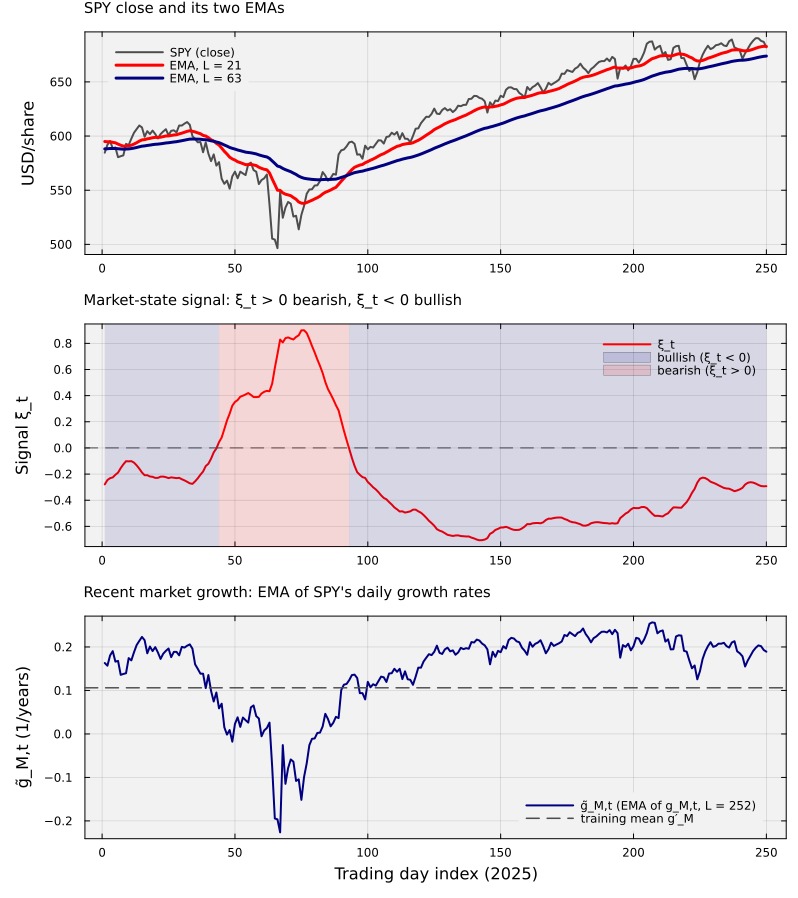

In [10]:
let
    # top panel: SPY close price and its two EMAs through 2025 (EMAs carried across the year boundary) -
    spy_all = vcat(dataset["SPY"][:, :close], spy_2025);
    N_train = length(dataset["SPY"][:, :close]);
    N = length(spy_2025);
    window = (N_train + 1):(N_train + N); # the 2025 days
    S̄_short = compute_ema(spy_all, L_short);
    S̄_long = compute_ema(spy_all, L_long);
    p1 = plot(1:N, spy_2025, lw = 2, c = :gray30, label = "SPY (close)", ylabel = "USD/share", title = "SPY close and its two EMAs")
    plot!(p1, 1:N, S̄_short[window], lw = 3, c = :red, label = "EMA, L = $(L_short)")
    plot!(p1, 1:N, S̄_long[window], lw = 3, c = :navy, label = "EMA, L = $(L_long)")
    plot!(p1, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)

    # middle panel: the market-state signal used on each decision day, with the bearish and bullish runs shaded -
    p2 = plot(1:N, ξ_2025, lw = 2, c = :red, label = "ξ_t", ylabel = "Signal ξ_t", title = "Market-state signal: ξ_t > 0 bearish, ξ_t < 0 bullish")
    hline!(p2, [0.0], lw = 1, ls = :dash, c = :gray30, label = "")
    bearish = ξ_2025 .> 0.0;
    starts = vcat(1, findall(diff(bearish) .!= 0) .+ 1); # first day of each run with the same sign
    stops = vcat(starts[2:end], N);                        # the span runs to the first day of the next run
    first_bear, first_bull = true, true;
    for (a, b) in zip(starts, stops)
        if bearish[a]
            vspan!(p2, [a, b], c = :red, alpha = 0.12, label = first_bear ? "bearish (ξ_t > 0)" : "")
            first_bear = false;
        else
            vspan!(p2, [a, b], c = :navy, alpha = 0.12, label = first_bull ? "bullish (ξ_t < 0)" : "")
            first_bull = false;
        end
    end
    plot!(p2, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, bg_legend = :transparent, legend = :topright)

    # bottom panel: the recent market growth used on each decision day, with the training mean for reference -
    p3 = plot(1:N, g̃_M_2025, lw = 2, c = :navy, label = "g̃_M,t (EMA of g_M,t, L = $(L_growth))", ylabel = "g̃_M,t (1/years)",
        title = "Recent market growth: EMA of SPY's daily growth rates")
    hline!(p3, [g_market_mean], lw = 1.5, ls = :dash, c = :gray30, label = "training mean g′_M")
    plot!(p3, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent,
        legend = :bottomright, xlabel = "Trading day index (2025)")

    plot(p1, p2, p3, layout = (3, 1), size = (800, 900), left_margin = 5Plots.mm, titlefontsize = 10, titlelocation = :left)
end

___

## Task 2: Compute the Preference Weights and Choose the Basket
In this task, we compute each firm's preference weight on every trading day of 2025, read which firms belong in the basket, and split the budget on the first trading day with Cobb–Douglas utility.

### Compute the preference weights
Recall from the lecture that the preference weight of firm $i$ on day $t$ is given by:

$$
\gamma_{i}(t) = \tanh\left(\frac{\alpha_{i}}{\beta_{i}^{\xi_{t}}} + \beta_{i}^{1-\xi_{t}}\,\tilde{g}_{M,t}\right)
$$

We read the preference weight in two parts:

* __Sign, which firms are in the basket:__ the argument of the $\tanh$ is $\tilde{g}_{i,t}/\beta_{i}^{\xi_{t}}$, where $\tilde{g}_{i,t} = \alpha_{i} + \beta_{i}\tilde{g}_{M,t}$ is the SIM's expected growth rate of firm $i$ in today's market. Recall that $\tanh(x) < 0$ for $x < 0$, $\tanh(0) = 0$, and $\tanh(x) > 0$ for $x > 0$. Since $\beta_{i}^{\xi_{t}} > 0$, the sign of $\gamma_{i}(t)$ is the sign of $\tilde{g}_{i,t}$: firm $i$ is preferred when $\tilde{g}_{i,t} > 0$, that is, when $\tilde{g}_{M,t}$ is above its threshold $-\alpha_{i}/\beta_{i}$. The preferred firms form the __basket__.
* __Magnitude, how much each firm gets:__ the signal $\xi_{t}$, scaled so that $-1 \leq \xi_{t} \leq 1$ on nearly every day, never changes a sign. It tilts the magnitudes toward low-beta firms when $\xi_{t} > 0$ (bearish), not at all when $\xi_{t} = 0$ (neutral), and toward high-beta firms when $\xi_{t} < 0$ (bullish).

The basket receives the budget left after the share floors, and a non-preferred firm is held at the floor of $n_{\min}$ shares.

Let's compute the preference weights for every 2025 day from the lagged inputs and store them in the matrix `Γ::Array{Float64,2}` (rows are trading days, columns are firms). We then display the first trading day, January 2, 2025, with two extra columns that recompute the weights at a fully bearish ($\xi = 1$) and a fully bullish ($\xi = -1$) signal with the recent market growth held fixed:

In [11]:
Γ = hcat([tanh.(α̂ ./ β̂ .^ ξ_2025[t] .+ β̂ .^ (1 - ξ_2025[t]) .* g̃_M_2025[t]) for t ∈ 1:length(ξ_2025)]...)' |> Matrix; # N × |𝒫| preference weights

let
    # table: SIM parameters, threshold -α/β, preference weight, and set on the first trading day of 2025,
    # plus the weights at a fixed bearish and bullish signal with g̃_M held at its day-1 value -
    γ₁ = Γ[1, :];
    γ_bear = tanh.(α̂ ./ β̂ .^ 1.0 .+ β̂ .^ 0.0 .* g̃_M_2025[1]); # ξ = 1
    γ_bull = tanh.(α̂ ./ β̂ .^ -1.0 .+ β̂ .^ 2.0 .* g̃_M_2025[1]); # ξ = -1
    df = DataFrame(ticker = my_list_of_tickers, α̂ = round.(α̂, digits=4), β̂ = round.(β̂, digits=3),
        threshold = round.(-α̂ ./ β̂, digits=3), γ = round.(γ₁, digits=4),
        set = [g > 0 ? "preferred" : "non-preferred" for g ∈ γ₁],
        γ_bearish = round.(γ_bear, digits=4), γ_bullish = round.(γ_bull, digits=4));
    day_1 = Date(dataset_2025["AAPL"][1, :timestamp]); # the first trading day of 2025
    cutoff = Date(dataset["SPY"][end, :timestamp]); # the last day of SPY data the day-1 inputs can see
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact), # show every row and column
        column_labels = ["ticker", "α̂", "β̂", "threshold", "γ (ξ = $(round(ξ_2025[1], digits=3)))", "set", "γ (ξ = 1, bearish)", "γ (ξ = -1, bullish)"],
        title = "Preference weights on $(day_1), the first trading day of 2025",
        subtitle = "from SIM parameters fitted on 2014 to 2024 and SPY prices through $(cutoff)", title_alignment = :l, subtitle_alignment = :l)

    # how the signal moves the weights: the highest- and lowest-β firms at the two limits of the signal -
    i_hi, i_lo = argmax(β̂), argmin(β̂);
    println("signal tilt with g̃_M held at its day-1 value: highest β is $(my_list_of_tickers[i_hi]) (β = $(round(β̂[i_hi], digits=3))), ",
        "γ = $(round(γ_bear[i_hi], digits=3)) bearish vs $(round(γ_bull[i_hi], digits=3)) bullish; ",
        "lowest β is $(my_list_of_tickers[i_lo]) (β = $(round(β̂[i_lo], digits=3))), γ = $(round(γ_bear[i_lo], digits=3)) bearish vs $(round(γ_bull[i_lo], digits=3)) bullish")

    # preferred set on the first trading day -
    println("first trading day of 2025: ξ = $(round(ξ_2025[1], digits=3)), g̃_M = $(round(g̃_M_2025[1], digits=3)) 1/yr; ",
        "preferred set: {$(join(my_list_of_tickers[γ₁ .> 0], ", "))}; ",
        "$(count(γ₁ .<= 0)) firms non-preferred, held at the floor n_min = $(n_min) shares")
end

Preference weights on 2025-01-02, the first trading day of 2025
from SIM parameters fitted on 2014 to 2024 and SPY prices through 2024-12-31
 -------- --------- ------- ----------- ---------------- ----------- -------------------- ---------------------
  ticker         α̂       β̂   threshold   γ (ξ = -0.279)         set   γ (ξ = 1, bearish)   γ (ξ = -1, bullish) 
 -------- --------- ------- ----------- ---------------- ----------- -------------------- ---------------------
    GOOG   -0.0138   1.193       0.012           0.1876   preferred               0.1504                0.2123
     DIS    -0.085   1.125       0.076           0.1014   preferred               0.0873                0.1103
     NWS   -0.0759   1.179       0.064           0.1212   preferred               0.0984                0.1362
      HD    0.0319   1.036      -0.031           0.2001   preferred               0.1915                0.2051
     NKE   -0.0648   1.178       0.055           0.1325   preferred          

__What do we see?__ The `threshold` column is $-\alpha_{i}/\beta_{i}$, the recent market growth at which the SIM expected growth of firm $i$ is zero. When $\tilde{g}_{M,t}$ is above it, the firm is preferred and joins the basket. This is separate from the bullish or bearish signal, which only tilts the magnitudes:

* __Positive $\alpha_{i}$:__ the threshold is negative, so the firm is preferred even when the recent market growth is zero.
* __Negative $\alpha_{i}$:__ the threshold is positive, so the firm is preferred only when the recent market growth is above it. For the same negative $\alpha_{i}$, a larger $\beta_{i}$ gives a lower threshold.
* __The last two columns:__ the same weights with the signal forced to its bearish and bullish limits, with the recent market growth held at its day-1 value. The signs, and so the basket, do not change. The sizes do, in opposite directions: a firm with $\beta_{i}$ above one gets a larger weight when the signal is bullish, and a firm with $\beta_{i}$ below one gets a larger weight when the signal is bearish. The line under the table shows the two columns for the highest- and lowest-$\beta_{i}$ firms in our list.

On the first trading day, the recent market growth sits above the largest threshold in the table, so every firm clears it. Your results may differ if you change the firms.

### How does the basket change through the year?
The firms with the highest thresholds are the first to leave when the market weakens. Let's count the preferred firms on each 2025 day, and tabulate each firm's threshold and the number of days it is non-preferred, highest threshold first:

In [12]:
preferred_count = let

    # preferred firms each day -
    N = size(Γ, 1);
    number_of_firms = length(my_list_of_tickers);
    preferred_count = [count(Γ[t, :] .> 0) for t ∈ 1:N];
    println("2025 ($(N) trading days): empty basket on $(count(preferred_count .== 0)) days, ",
        "all $(number_of_firms) firms on $(count(preferred_count .== number_of_firms)) days, ",
        "partial basket on $(count(0 .< preferred_count .< number_of_firms)) days")

    # table: each firm's threshold (1/yr) and the days it is non-preferred, highest threshold first -
    df = DataFrame(ticker = my_list_of_tickers, threshold = round.(-α̂ ./ β̂, digits=3),
        days_non_preferred = [count(Γ[:, i] .<= 0) for i ∈ eachindex(my_list_of_tickers)]);
    sort!(df, :threshold, rev = true); # highest threshold first
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)) # show every row and column

    preferred_count; # return
end;

2025 (250 trading days): empty basket on 8 days, all 30 firms on 178 days, partial basket on 64 days
 -------- ----------- --------------------
  ticker   threshold   days_non_preferred 
  String     Float64                Int64 
 -------- ----------- --------------------
     BXP       0.132                   72
     AES       0.114                   58
      EL       0.105                   53
     ADM       0.089                   48
     PPG       0.088                   48
     DIS       0.076                   47
     CNP        0.07                   46
     NWS       0.064                   44
     ARE       0.064                   44
     NKE       0.055                   42
       L       0.055                   42
     SYY       0.042                   41
     ECL       0.038                   38
     HON       0.028                   33
    GOOG       0.012                   24
     PLD       0.011                   24
     NRG        0.01                   24
     AME     

`Unhide` the code block below to see the size of the preferred set $|\mathcal{A}^{+}|$ through 2025. The basket shrinks when the recent market growth drops below the thresholds of the marginal firms and recovers when it rises:

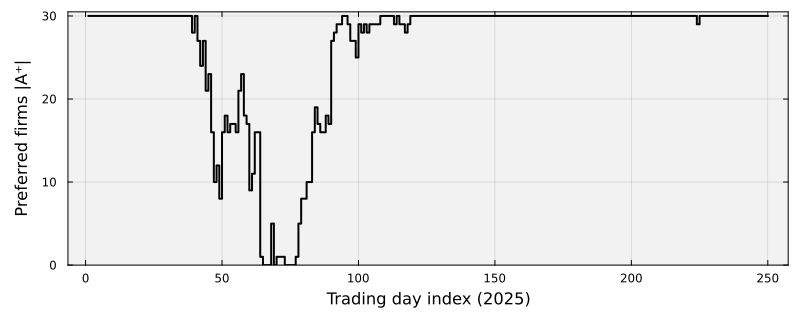

In [13]:
let
    N = length(preferred_count);
    p = plot(1:N, preferred_count, lw = 2, c = :black, label = "", linetype = :steppost,
        ylabel = "Preferred firms |A⁺|", xlabel = "Trading day index (2025)", ylim = (0, length(my_list_of_tickers) + 0.5))
    plot!(p, bg = "gray95", background_color_outside = "white", framestyle = :box, size = (800, 320),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

### Allocate the budget with Cobb–Douglas utility
As in the lecture, when no preferred floor binds, the Cobb–Douglas allocation of a preferred firm is given by:

$$
n_{i}^{\star} = \underbrace{\frac{\gamma_{i}}{\sum_{j\in\mathcal{A}^{+}}\gamma_{j}}}_{\text{preference share}}\cdot\underbrace{\frac{W_{\text{adj}}}{S_{i}(t)}}_{\text{budget in shares}}\qquad i\in\mathcal{A}^{+}
$$

where $\mathcal{A}^{+}$ is the preferred set, $\mathcal{A}^{-}$ is the non-preferred set, and $W_{\text{adj}} = W_{\mathcal{P}}(0) - n_{\min}\sum_{k\in\mathcal{A}^{-}}S_{k}(t)$ is the budget left after the floors on the non-preferred firms. When no preferred floor binds, the dollar weight of a preferred firm within that budget is its normalized preference weight, independent of prices.

Let's compute the allocation on the first trading day from this formula and check it against [the `allocate_cobb_douglas(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_cobb_douglas). We store the package result in `cd::NamedTuple` (fields `shares`, `dollars`, `weights`, `cash`) and the weights of total wealth in `w_CD::Array{Float64,1}`:

In [14]:
cd, w_CD = let

    # first trading day: preference weights and close prices -
    γ = Γ[1, :];
    S₁ = S_2025[1, :]; # USD/share

    # package -
    cd = allocate_cobb_douglas(S₁, γ, W₀; epsilon = n_min);

    # by hand: preferred and non-preferred sets, adjusted budget, closed form -
    A_plus = findall(γ .> 0);
    A_minus = findall(γ .<= 0);
    W_adj = W₀ - n_min*sum(S₁[A_minus]); # budget left after the floors (USD)
    n_hand = fill(n_min, length(γ)); # every firm starts at the floor
    closed_form = !isempty(A_plus) && all((γ[A_plus] ./ sum(γ[A_plus])) .* W_adj ./ S₁[A_plus] .>= n_min); # true when no preferred floor binds
    if (closed_form)
        n_hand[A_plus] .= (γ[A_plus] ./ sum(γ[A_plus])) .* W_adj ./ S₁[A_plus]; # closed form
        message = "Cobb–Douglas on the first trading day: preferred budget W_adj = $(round(W_adj, digits=2)) USD, " *
            "floors = $(round(W₀ - W_adj, digits=2)) USD, cash = $(round(cd.cash, digits=2)) USD; closed form matches the package";
    elseif (isempty(A_plus))
        message = "no firm is preferred on the first trading day, so the allocation is the floors plus $(round(cd.cash, digits=2)) USD of cash; the closed form does not apply";
    else
        message = "a preferred floor binds on the first trading day, so the package pins that firm at its floor and solves again; the one-step closed form does not apply";
    end

    # checks -
    @assert W_adj > 0 # the floors are affordable
    @assert isapprox(sum(cd.dollars) + cd.cash, W₀; atol = 1e-8) # budget spent
    @assert isapprox(allocate_ces(S₁, γ, W₀, 1.0; epsilon = n_min).dollars, cd.dollars; atol = 1e-8) # CES at an elasticity of one is Cobb–Douglas
    if (closed_form)
        @assert isapprox(cd.shares, n_hand; atol = 1e-8) # same shares as the package
        @assert isapprox(cd.dollars[A_plus] ./ W_adj, γ[A_plus] ./ sum(γ[A_plus]); atol = 1e-10) # normalized preferences
    end
    println(message)

    (cd, cd.dollars ./ W₀); # weights of total wealth
end;

Cobb–Douglas on the first trading day: preferred budget W_adj = 1000.0 USD, floors = 0.0 USD, cash = 0.0 USD; closed form matches the package


### Compare with the L7a portfolios
How does the utility allocation compare with the L7a portfolios? We build the SIM mean vector and covariance matrix as in L7a from the archive's intercepts, betas, residual variances, and the training market mean and variance, then solve two problems:

* __Long-only GMV portfolio $\mathbf{w}_{\text{GMV}}$:__ the risky-asset-only problem using [the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem), with the target set to the smallest expected growth rate so that it never binds. The solver returns the minimum-variance point of the long-only frontier.
* __Tangent portfolio $\mathbf{w}_{\mathcal{T}}$:__ the risky and risk-free problem using [the `MyMarkowitzRiskyRiskFreePortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyRiskFreePortfolioChoiceProblem), solved once at a small growth target and rescaled so the risky weights sum to one. This is a one-solve shortcut of [the tangent continuation algorithm](CHEME-5660-L7b-Algorithm-TangentContinuation-Fall-2026.ipynb). We run the full continuation below as a check.

We store the SIM inputs in `ĝ_sim::Array{Float64,1}` and `Σ̂_g_sim::Array{Float64,2}`, and the weights in `w_GMV::Array{Float64,1}` and `w_T::Array{Float64,1}`:

In [15]:
ĝ_sim, Σ̂_g_sim, w_GMV, w_T = let

    # SIM inputs (L7a) -
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (1/years²)
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    # long-only bounds 0 ≤ wᵢ ≤ 1 on the risky weights, and an equal-weight starting point -
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2);
    bounds[:, 2] .= 1.0;
    initial = (1/number_of_assets)*ones(number_of_assets);

    # long-only GMV portfolio: risky-asset-only problem with a growth floor every long-only portfolio meets -
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim,
        bounds = bounds, initial = initial, R = minimum(ĝ_sim)));
    solution = solve(problem);
    w_GMV = solution["argmax"] |> w -> max.(w, 0.0) |> w -> w ./ sum(w); # clip solver noise of order 1e-9 below zero

    # tangent portfolio: normalize the risky weights of a risky and risk-free solution at a small excess growth target (ray argument, L7a) -
    g_target = g_f + (maximum(ĝ_sim) - g_f)/4; # growth target (1/yr): any target above g_f gives the same risky mix while no upper bound binds
    problem_rf = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim,
        bounds = bounds, initial = initial, risk_free_rate = g_f, R = g_target));
    solution_rf = solve(problem_rf);
    w_risky = solution_rf["argmax"];
    w_T = max.(w_risky, 0.0) |> w -> w ./ sum(w); # clip solver noise of order 1e-9 below zero
    println("tangent solve: risky fraction $(round(sum(w_risky), digits=3)) at the target g⋆ = $(round(g_target, digits=3)) 1/yr; ",
        "normalized to the tangent portfolio with $(count(w_T .> 1e-6)) firms above zero weight")

    # checks -
    @assert all(s²_ε .> 0) # positive residual variances make the SIM covariance positive definite
    @assert maximum(ĝ_sim) > g_f # the tangent portfolio needs at least one firm whose SIM expected growth exceeds the risk-free rate
    @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED # MadNLP's success status, GMV solve
    @assert minimum(solution["argmax"]) > -1e-6 # negative GMV weights are solver noise only
    @assert solution_rf["status"] == MathOptInterface.LOCALLY_SOLVED # MadNLP's success status, tangent solve
    @assert sum(w_risky) > 1e-2 # enough in risky assets that rescaling does not magnify roundoff
    @assert maximum(w_risky) < 1 - 1e-6 # no weight sits at its upper bound, so the ray argument applies
    @assert minimum(w_risky) > -1e-6 # negative tangent weights are solver noise only

    (ĝ_sim, Σ̂_g_sim, w_GMV, w_T); # return
end;

tangent solve: risky fraction 0.277 at the target g⋆ = 0.086 1/yr; normalized to the tangent portfolio with 4 firms above zero weight


### Check the tangent portfolio by continuation
[The continuation algorithm](CHEME-5660-L7b-Algorithm-TangentContinuation-Fall-2026.ipynb) finds the tangent point itself: it steps the growth target up until lending turns into borrowing, then bisects the crossing to a risky fraction of one. We run it here and check that it returns the same portfolio as the single solve. We store the result in `w_T_continuation::Array{Float64,1}`:


In [16]:
w_T_continuation = let

    # continuation parameters -
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2);
    bounds[:, 2] .= 1.0; # long-only bounds 0 ≤ wᵢ ≤ 1
    g_U = maximum(ĝ_sim); # top of the target interval (1/yr): the highest-growth firm alone meets it
    g_L = g_f; # bottom of the target interval (1/yr)
    Δg = (g_U - g_f)/10; # growth-target increment for the upward sweep (1/yr)
    ϵ = 1e-3; # risky-fraction tolerance: stop when |θ - 1| < ϵ
    maxiter = 50; # iteration limit

    # initialize: at g⋆ = g_f the allocation holds nothing risky -
    g_target = g_f; # current growth target (1/yr)
    w = zeros(number_of_assets); # current risky weights
    θ = 0.0; # current risky fraction
    k = 0; # solve counter
    bracketed = false;
    converged = false;
    problem = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim,
        bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), risk_free_rate = g_f, R = g_target));

    while (converged == false)
        r = θ - 1; # risky-fraction residual: negative while lending, positive while borrowing
        if (abs(r) < ϵ && maximum(w) < 1 - 1e-6)
            converged = true; # tolerance met with no weight at its cap: w/θ approximates w_T
        elseif (k ≥ maxiter)
            @warn "risky-fraction tolerance not met after $(k) solves"; break;
        else
            if (r < 0 && maximum(w) < 1 - 1e-6)
                g_L = g_target; # the current allocation still lends, with no weight at its cap
            else
                g_U = g_target; # we have crossed into borrowing, or hit a cap
                bracketed = true;
            end
            g_target = bracketed ? (g_L + g_U)/2 : min(g_target + Δg, g_U); # bisect once bracketed, otherwise sweep upward
            problem.R = g_target; # the new growth target
            problem.initial = w; # warm start from the current weights
            solution = try
                solve(problem) # raises an AssertionError unless the solver succeeds
            catch err
                err isa AssertionError || rethrow()
                @warn "solver failed at g⋆ = $(g_target) 1/yr"; break;
            end
            w = solution["argmax"]; # risky weights at the new target
            θ = sum(w); # risky fraction 1ᵀw
            k += 1;
        end
    end
    w_T_cont = max.(w, 0.0) |> w -> w ./ sum(w); # clip solver noise below zero, rescale to sum to one
    println("continuation: $(k) solves, tangent target g⋆ = $(round(g_target, digits=4)) 1/yr versus E[g_T] = $(round(ĝ_sim'*w_T, digits=4)) 1/yr, ",
        "largest weight difference from the single solve = $(round(maximum(abs.(w_T_cont .- w_T)), sigdigits=2))")

    # checks -
    @assert converged # the comparison needs the tangent point
    @assert maximum(abs.(w_T_cont .- w_T)) < 1e-4 # the two routes agree to solver tolerance

    w_T_cont; # return
end;


continuation: 16 solves, tangent target g⋆ = 0.2043 1/yr versus E[g_T] = 0.2044 1/yr, largest weight difference from the single solve = 3.4e-7


Let's compare the three weight vectors we hold after the first trade, at the close of January 2, 2025, the first trading day. 

The GMV and tangent weights come from the training data through December 31, 2024, and the Cobb–Douglas weights from the signal and the recent market growth computed from SPY through that same day. The Cobb–Douglas share counts use the January 2 close prices, but the weights do not depend on prices when every firm is preferred and no floor binds, which the floors of 0 USD printed above confirm. So no 2025 data enters this table. 

The table lists each portfolio's expected growth rate and risk (both in $\mathrm{year}^{-1}$), annualized Sharpe ratio, beta, largest weight and the firm that holds it, and the sum of its weights:

In [17]:
let
    # table: expected growth, risk, annualized Sharpe ratio, beta, and largest weight of each portfolio under the SIM inputs -
    df = DataFrame(portfolio = String[], E_g = Float64[], σ_g = Float64[], SR = Float64[], β_P = Float64[],
        w_max = Float64[], firm = String[], Σw = Float64[]);
    
    for (name, w) ∈ [("Cobb–Douglas", w_CD), ("GMV", w_GMV), ("tangent", w_T)]
        g = ĝ_sim'*w; # expected growth rate (1/yr)
        σ = sqrt(w'*Σ̂_g_sim*w); # growth-rate standard deviation (1/yr)
        SR = (g - g_f)/σ/sqrt(Δt); # annualized Sharpe ratio: excess growth over the volatility σ√Δt
        push!(df, (portfolio = name, E_g = round(g, digits=4), σ_g = round(σ, digits=4), SR = round(SR, digits=3),
            β_P = round(β̂'*w, digits=3), w_max = round(maximum(w), digits=3), firm = my_list_of_tickers[argmax(w)], Σw = round(sum(w), digits=4)));
    end
    
    # make a pretty table with the portfolio statistics -
    day_1 = Date(dataset_2025["AAPL"][1, :timestamp]); # the first trading day of 2025
    train_start = Date(dataset["SPY"][1, :timestamp]); # first and last day of the SIM training data
    train_stop = Date(dataset["SPY"][end, :timestamp]);
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact), # show every row and column
        title = "Expected performance of the weights held at the close of $(day_1)",
        subtitle = "under the SIM fitted on $(train_start) to $(train_stop)", title_alignment = :l, subtitle_alignment = :l)
end

Expected performance of the weights held at the close of 2025-01-02
under the SIM fitted on 2014-01-03 to 2024-12-31
 -------------- --------- --------- --------- --------- --------- -------- ---------
     portfolio       E_g       σ_g        SR       β_P     w_max     firm        Σw 
        String   Float64   Float64   Float64   Float64   Float64   String   Float64 
 -------------- --------- --------- --------- --------- --------- -------- ---------
  Cobb–Douglas    0.1111    2.4188      0.46     1.097     0.064     MSFT       1.0
           GMV    0.0794    2.1756     0.281     0.925     0.334    BRK.B       1.0
       tangent    0.2044    3.0062     0.863     1.151       0.7     MSFT       1.0
 -------------- --------- --------- --------- --------- --------- -------- ---------


Let's plot the three weight vectors side by side:

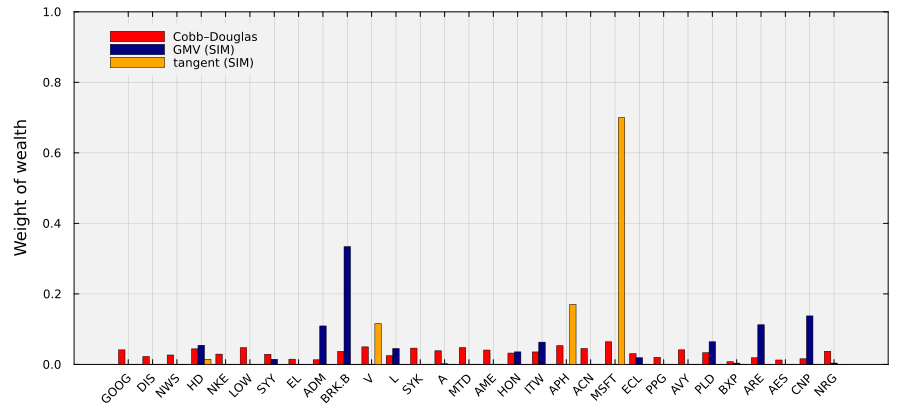

In [18]:
let
    # grouped bars: one group per firm, one bar per portfolio -
    number_of_assets = length(my_list_of_tickers);
    groupedbar(hcat(w_CD, w_GMV, w_T), bar_position = :dodge, bar_width = 0.8, lw = 0.5,
        c = [:red :navy :orange], label = ["Cobb–Douglas" "GMV (SIM)" "tangent (SIM)"],
        xticks = (1:number_of_assets, my_list_of_tickers), xrotation = 45, ylabel = "Weight of wealth", ylim = (0.0, 1.0),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent,
        legend = :topleft, size = (900, 420), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

__What do we see?__ Read the bars against the Task 2 table of SIM parameters and the comparison table above:

* __Tangent__ puts almost the whole budget on three firms: MSFT, APH, and V, the three largest intercepts $\hat{\alpha}$ in the Task 2 table, with 0.70 in MSFT alone; the solve printout counts four firms above zero weight. Maximizing the Sharpe ratio under the SIM inputs rewards alpha, and since every beta sits near one, spreading across firms does little to reduce the shared market risk. It has the largest expected growth, the largest risk, and the largest Sharpe ratio in the table.
* __GMV__ puts three quarters of the budget in the five firms with betas below one, BRK.B, CNP, ADM, ARE, and PLD, with a third in BRK.B alone, and spreads the rest thinly. Under the SIM, the portfolio variance is the market variance times the squared portfolio beta plus the residual variances weighted by the squared weights, so the solver pushes the portfolio beta down to 0.925 and accepts the lowest expected growth in the table.
* __Cobb–Douglas__ is the only one that holds every firm. Its bars follow the preference weights in the Task 2 table, from about 0.01 for BXP to 0.064 for MSFT, so its largest holdings are the same alpha leaders the tangent portfolio picks, but no firm gets more than a few percent. Its expected growth and beta sit between the other two.

Your results may differ if you change the firms.

___

## Task 3: Run the Allocator Through 2025
In this task, we run the allocator through 2025 on a daily and a monthly schedule, and compare its wealth path with the GMV, tangent, and SPY portfolios bought on the first day and held.

### Run six portfolios through the engine
We run every portfolio through [the `run_utility_engine(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.run_utility_engine) of the course package. It starts with the whole budget in cash and steps through 2025 one day at a time: the cash earns the risk-free rate, the shares are valued at the closing prices, and on a rebalance day a __target function__ we supply returns the weights we want to hold. 

The engine buys and sells shares at the closing prices to reach those weights and charges the cost rate $c$ on every dollar traded. The order is sized with the same close it fills at, an idealization, since a real order is placed before the close is known. We place no limit on how much it trades, and nothing pulls it out of the market during a drawdown.
* __Adaptive runs__: For the adaptive runs, the target function looks up that day's preference weights $\gamma_{i}(t)$, which we computed for every firm and every day of 2025 in Task 2 and stored in the matrix `Γ`, and computes the number of shares $n_{i}$ of each firm to hold from those preferences, either with Cobb–Douglas utility using [the `allocate_cobb_douglas(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_cobb_douglas) or with CES utility at $\eta_{\text{CES}} = 0.5$ using [the `allocate_ces(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_ces). The engine works in fractions of wealth, so the target function converts the share counts to weights, $w_{i}(t) = n_{i}^{\star}S_{i}(t)/W_{\mathcal{P}}(t)$, where $S_{i}(t)$ is the closing price of firm $i$ and $W_{\mathcal{P}}(t)$ is the wealth on day $t$.
* __Buy-and-hold runs__: For the buy-and-hold runs, the target function returns the fixed GMV, tangent, or SPY weights. Nothing is refit during the year: the SIM parameters, the GMV and tangent weights, and the gain $G$ all come from the training data. 

The six runs are:

* `adaptive, daily` and `adaptive, monthly`: Cobb–Douglas share counts recomputed every day and every 21 trading days.
* `CES, monthly`: CES on the monthly schedule.
* `GMV (buy and hold)`, `tangent (buy and hold)`, and `SPY (buy and hold)`: bought on day 1 and held.

We collect the results in `runs::Dict{String,NamedTuple}`:

In [19]:
runs = let

    # schedules -
    N = size(S_2025, 1); # trading days in 2025
    R_monthly = collect(1:schedule_days:N); # day 1 and every 21 trading days after it
    R_daily = collect(1:N);

    # target functions: risky weights from the lagged preference weights, sized on the day's wealth at the day's close prices -
    target_cd = (t, state) -> begin
        alloc = allocate_cobb_douglas(state.prices, Γ[t, :], state.wealth; epsilon = n_min);
        alloc.dollars ./ state.wealth; # risky weights of wealth (sum ≤ 1; the remainder is cash)
    end;
    target_ces = (t, state) -> begin
        alloc = allocate_ces(state.prices, Γ[t, :], state.wealth, η_CES; epsilon = n_min);
        alloc.dollars ./ state.wealth;
    end;

    # runs: adaptive allocators and buy-and-hold portfolios through the same engine -
    runs = Dict{String, NamedTuple}();
    runs["adaptive, daily"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_daily, cost_rate = c, g_f = g_f, Δt = Δt);
    runs["adaptive, monthly"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, g_f = g_f, Δt = Δt);
    runs["CES, monthly"] = run_utility_engine(S_2025, target_ces; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, g_f = g_f, Δt = Δt);
    runs["GMV (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_GMV; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["tangent (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_T; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["SPY (buy and hold)"] = run_utility_engine(reshape(spy_2025, :, 1), (t, state) -> [1.0]; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);

    runs; # return
end;

__Self-financing constraint:__ after the first day's purchase, no money is added to or withdrawn from the account. On every day the wealth is the cash plus the value of the shares at the closing prices, $W_{\mathcal{P}}(t) = \text{cash}(t) + \sum_{i}n_{i}(t)\,S_{i}(t)$, and it changes only through the prices, the interest on the cash, and the trading costs.

__Turnover:__ the dollars that move from one holding to another on a rebalance day, as a fraction of wealth. With cash counted as a holding, every dollar sold is bought somewhere else, so we count only the sells, which is half of all the weight changes:

$$
\tau_{t} = \frac{1}{2}\sum_{i}\left|w_{i}^{\star} - w_{i}\right|
$$

where $w_{i}$ and $w_{i}^{\star}$ are the weights before and after the trade. On the first day the cash weight falls from one to zero and the firm weights rise from zero to a total of one, so the sum is two and $\tau_{1} = 1$: the whole budget changed hands once. The table reports the sum of $\tau_{t}$ over the rebalance days of the year.

Let's check the self-financing identity on every day of each adaptive run, and tabulate how much each one traded: the number of rebalances, the one-way turnover summed over the rebalance days, the total cost ($c$ times the dollars traded, in USD), and the cash left at the end of the year:

In [20]:
let
    # table of rebalances, turnover, cost, and final cash for each adaptive run -
    N = size(S_2025, 1);
    adaptive_runs = ["adaptive, daily", "adaptive, monthly", "CES, monthly"];
    df = DataFrame(run = String[], rebalances = Int[], turnover = Float64[], cost = Float64[], final_cash = Float64[]);
    for name ∈ adaptive_runs
        r = runs[name];
        push!(df, (run = name, rebalances = count(r.rebalanced), turnover = round(sum(r.turnover), digits=3),
            cost = round(sum(r.cost), digits=2), final_cash = round(r.cash[end], digits=2)));
    end

    # checks: self-financing on every day of each adaptive run -
    for name ∈ adaptive_runs
        r = runs[name];
        @assert all(isapprox.(r.wealth[2:end], r.cash[2:end] .+ [dot(r.shares[t+1, :], S_2025[t, :]) for t ∈ 1:N]; atol = 1e-6)) # wealth = cash + shares at the close
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)) # show every row and column
end

 ------------------- ------------ ---------- --------- ------------
                run   rebalances   turnover      cost   final_cash 
             String        Int64    Float64   Float64      Float64 
 ------------------- ------------ ---------- --------- ------------
    adaptive, daily          250     14.217     10.44          0.0
  adaptive, monthly           12      3.317      2.87          0.0
       CES, monthly           12      3.087       2.6          0.0
 ------------------- ------------ ---------- --------- ------------


### Compare the wealth paths
Let's plot the scaled wealth $W_{\mathcal{P}}(t)/W_{\mathcal{P}}(0)$ of every run through 2025. The adaptive runs change their share counts on each rebalance day as the preference weights and prices move. After the first day's purchase and its cost, the buy-and-hold runs keep fixed shares, so their wealth moves only with prices:

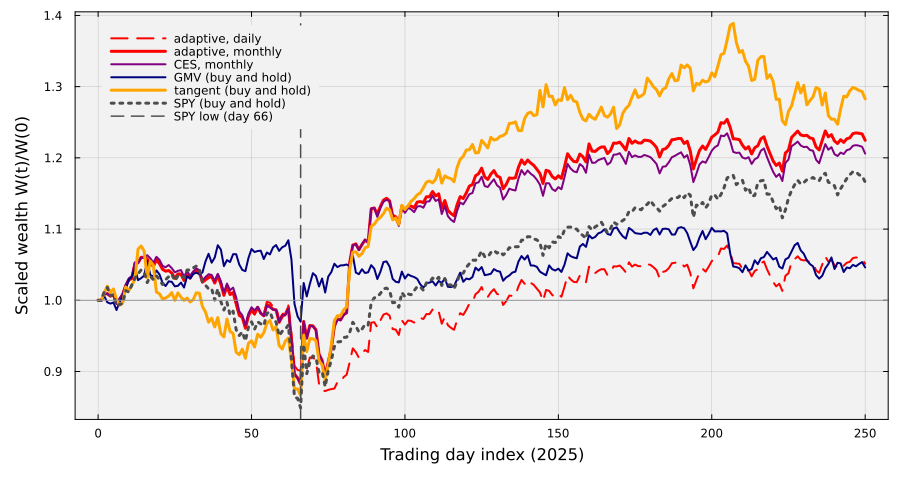

In [21]:
let
    styles = [("adaptive, daily", :red, :dash, 2), ("adaptive, monthly", :red, :solid, 3), ("CES, monthly", :purple, :solid, 2),
        ("GMV (buy and hold)", :navy, :solid, 2), ("tangent (buy and hold)", :orange, :solid, 3), ("SPY (buy and hold)", :gray30, :dot, 3)];
    p = plot();
    for (name, color, style, width) ∈ styles
        plot!(p, 0:length(runs[name].wealth)-1, runs[name].wealth ./ W₀, lw = width, c = color, ls = style, label = name)
    end
    hline!(p, [1.0], lw = 1, c = :gray60, label = "")
    t_low = argmin(spy_2025); # the day of SPY's lowest close in 2025: the bottom of the market
    vline!(p, [t_low], lw = 1.5, ls = :dash, c = :gray30, label = "SPY low (day $(t_low))")
    plot!(p, xlabel = "Trading day index (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft, size = (900, 480),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

__What do we see?__ Read the paths against the spring drawdown, roughly days 40 to 75, when every run fell together:

* __The tangent portfolio fell the most and finished the highest.__ With 0.70 of the budget in MSFT, it has the deepest dip and the strongest rebound of any path. GMV, mostly in low-beta firms, barely moves either way: the shallowest dip and the lowest finish among the buy-and-hold runs.
* __The two monthly adaptive runs track each other and beat SPY.__ Cobb–Douglas and CES on the monthly schedule are nearly the same path, and both finish above SPY. They hold their shares between rebalances, so they rode the fall down and the rebound back up.
* __The daily run missed the rebound.__ The daily and monthly paths are nearly the same until the SPY low at the dashed line. Around the low the basket emptied for eight days (Task 2), so the daily run sold to the floors and held cash while the market turned up. The monthly run kept its shares and caught the rebound, and the gap never closed.

Your results may differ if you change the firms, the windows, the schedule, or the elasticity.

### Score the realized paths
Finally, we score every run on its 2025 wealth path using [the `realized_scorecard(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.realized_scorecard). The scorecard reports the terminal wealth (the wealth on the last day), its net present value, the maximum drawdown, the annualized Sharpe ratio of the daily growth in wealth, and the total turnover and cost.

__Net present value:__ as in L6a, the NPV discounts the terminal wealth at a constant benchmark growth rate and subtracts the initial investment. We take the risk-free rate as the benchmark, so with $T$ the length of the year in years:

$$
\text{NPV} = -W_{\mathcal{P}}(0) + W_{\mathcal{P}}(T)\,e^{-g_{f}T}
$$

A positive NPV means the run ended with more than cash held at the risk-free rate would have, and a negative NPV means less.

__Maximum drawdown:__ let $W^{\text{peak}}(t) = \max_{s\leq t}W_{\mathcal{P}}(s)$ be the highest wealth seen up to day $t$. The drawdown on day $t$ is the drop from that peak, as a fraction of the peak, and the maximum drawdown is the worst drawdown over the year:

$$
d_{t} = \frac{W^{\text{peak}}(t) - W_{\mathcal{P}}(t)}{W^{\text{peak}}(t)}\qquad\text{and}\qquad\text{maximum drawdown} = \max_{t}\,d_{t}
$$

A maximum drawdown of 0.17 means that on some day the account stood 17 percent below its best day up to then. Let's score every run, and print the cash benchmark, the initial wealth held at the risk-free rate for the year:

In [22]:
let
    order = ["adaptive, daily", "adaptive, monthly", "CES, monthly", "GMV (buy and hold)", "tangent (buy and hold)", "SPY (buy and hold)"];
    df = DataFrame(run = String[], W_T = Float64[], NPV = Float64[], max_drawdown = Float64[], sharpe = Float64[], turnover = Float64[], cost = Float64[]);
    for name ∈ order
        r = runs[name];
        sc = realized_scorecard(r.wealth; g_f = g_f, Δt = Δt, turnover = r.turnover, cost = r.cost);
        push!(df, (run = name, W_T = round(sc.terminal, digits=2), NPV = round(sc.npv, digits=2), max_drawdown = round(sc.max_drawdown, digits=4),
            sharpe = round(sc.realized_sharpe, digits=3), turnover = round(sc.total_turnover, digits=3), cost = round(sc.total_cost, digits=2)));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)) # show every row and column
    N = size(S_2025, 1);
    println("cash benchmark: W₀ held at the risk-free rate for $(N) trading days = $(round(W₀*exp(g_f*N*Δt), digits=2)) USD")
end

 ------------------------ --------- --------- -------------- --------- ---------- ---------
                     run       W_T       NPV   max_drawdown    sharpe   turnover      cost 
                  String   Float64   Float64        Float64   Float64    Float64   Float64 
 ------------------------ --------- --------- -------------- --------- ---------- ---------
         adaptive, daily   1051.29      9.39          0.177     0.062     14.217     10.44
       adaptive, monthly   1224.62    175.81         0.1682     0.811      3.317      2.87
            CES, monthly   1205.96    157.89         0.1708      0.73      3.087       2.6
      GMV (buy and hold)   1046.15      4.45         0.1054     0.028        1.0       0.5
  tangent (buy and hold)   1282.91    231.78          0.195     0.942        1.0       0.5
      SPY (buy and hold)    1166.0    119.52           0.19     0.589        1.0       0.5
 ------------------------ --------- --------- -------------- --------- ---------- ----

Read the table against the wealth plot and the cash benchmark printed below it:

* __The monthly allocator did well.__ Rebalancing once a month ended the year with 1225 USD, an NPV of 176 USD against the risk-free rate, ahead of SPY at 1166 USD with about the same drawdown. Only the tangent portfolio ended higher, with 1283 USD, and it fell the furthest from its peak. The CES run ended within 20 USD of the monthly run, so halving the elasticity made little difference this year.
* __The daily allocator ended near cash.__ Rebalancing every day ended with 1051 USD, an NPV of only 9 USD, and GMV did no better with an NPV of 4 USD. The daily run sold at the bottom and missed the rebound, which left it 173 USD behind the monthly run, while paying only 8 USD more in trading costs.
* __The Sharpe ratios tell the same story.__ Task 2 predicted a Sharpe ratio of 0.46 for the first-day Cobb–Douglas weights. The monthly run realized 0.81 and the daily run 0.06. The tangent portfolio was predicted at 0.86 and realized 0.94.

This is one year's path, so it tells us what happened in 2025, not what to expect next year.

___

## Summary
In this example, we computed the market inputs from SPY for every trading day of 2025, turned the SIM parameters of our firms into daily preference weights, read the basket from their signs, and ran the Cobb–Douglas allocator through the year against portfolios bought once and held.

> __Key Takeaways:__
>
> * __The market inputs set the basket and the tilt:__ We computed a one-year moving average of the market growth and a crossover signal from SPY prices through the previous day. The recent growth decided which firms cleared their thresholds and belonged in the basket, and the signal tilted the weights between high-beta and low-beta firms.
> * __Cobb–Douglas turns preferences into share counts in closed form:__ We split the preferred budget in proportion to the positive preference weights, held the other firms at a small floor, and checked the closed form against the course package. The L7a tangent portfolio trades expected growth against variance and the GMV portfolio minimizes variance alone, so each answers a different question.
> * __The schedule mattered more than the allocation:__ We ran the allocator daily and monthly through the self-financing engine, with one CES variant, against the GMV, tangent, and SPY portfolios bought and held. The monthly runs beat SPY, while the daily run sold to the floors when the basket emptied at the bottom, missed the rebound, and finished near cash. The CES variant tracked Cobb–Douglas, so the elasticity did not matter on this path.

We can now change the firms, the moving-average windows, the schedule, or the elasticity and see how the basket, the weights, and the wealth path respond.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___